In [8]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
vocab_list = pd.read_csv("../data/topwords10000.csv")
vocab_words = vocab_list["content"].tolist()
vectorizer = CountVectorizer(vocabulary=vocab_words)

In [3]:
model = joblib.load("../models/logistic_model.joblib")

In [4]:
data_liar = pd.read_csv("../data/liar_stemmed_data.csv")

In [5]:
X = vectorizer.transform(data_liar["content"])

In [6]:
pred_y = model.predict(X)

In [10]:
f1_score(data_liar["type"], pred_y, pos_label=1)

0.24582701062215478

### Confusion matrix

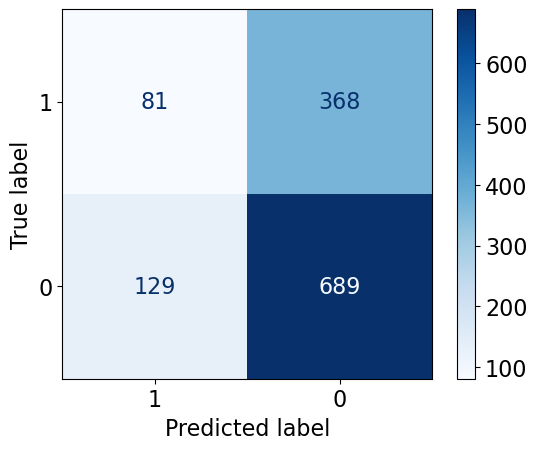

In [9]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    data_liar["type"], 
    pred_y, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)